<a href="https://colab.research.google.com/github/gabrielcuellarperez-prog/analysis_everpeak/blob/main/Everpeak_Angel_Gabriel_Perez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Everpeak - Analisis

# Análisis estadístico

In [ ]:
# importar librerías y dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/datasets/everpeak_clean.csv")

# 1. Visión general

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   order_id               5000 non-null   int64 
 1   order_date             5000 non-null   object
 2   customer_id            5000 non-null   int64 
 3   product_category       5000 non-null   object
 4   price                  5000 non-null   int64 
 5   quantity               5000 non-null   int64 
 6   order_value            5000 non-null   int64 
 7   payment_method         5000 non-null   object
 8   city                   5000 non-null   object
 9   state                  5000 non-null   object
 10  customer_age           5000 non-null   int64 
 11  quantity_invalid_flag  5000 non-null   int64 
 12  age_invalid_flag       5000 non-null   int64 
 13  state_missing_flag     5000 non-null   int64 
dtypes: int64(9), object(5)
memory usage: 547.0+ KB


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0
1,2,2024-10-10,1736,Grocery,66,10,660,debit_card,Los Angeles,CA,24,1,0,0
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0


Las columnas price, quantity, order_value y customer_age son de tipo INT.

Las analizamos porque permiten identificar patrones, distribuciones y valores atípicos útiles para el análisis.

# 2. Estadísticas descriptivas

In [ ]:
num_cols = ["price", "quantity", "order_value", "customer_age"]
df[num_cols].describe()

,price,quantity,order_value,customer_age
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,756.387400,32.359800,10075.523800,49.120800
std,1173.265182,93.403826,12406.603152,17.710679
min,12.000000,1.000000,12.000000,18.000000
25%,218.000000,7.000000,3094.000000,34.000000
50%,457.000000,14.000000,10341.000000,49.000000
75%,847.250000,23.000000,13160.500000,64.000000
max,36708.000000,2083.000000,303824.000000,80.000000


# 3. Visualización diagnóstica

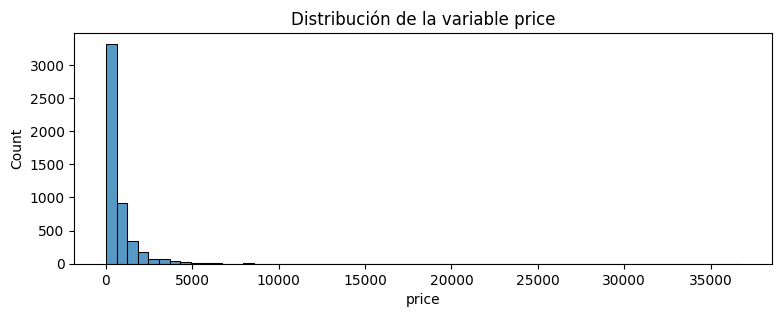

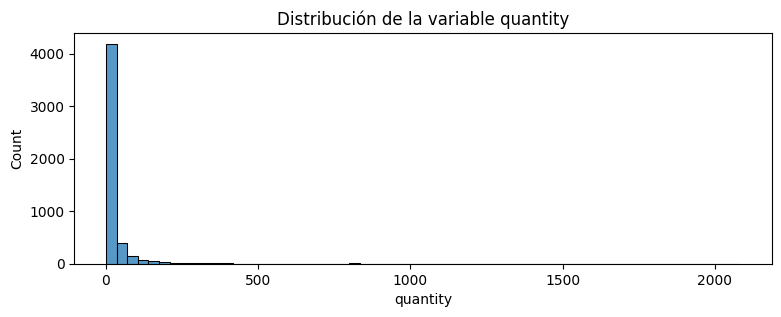

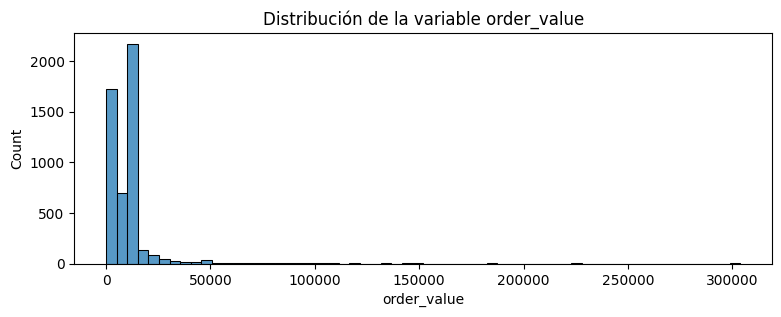

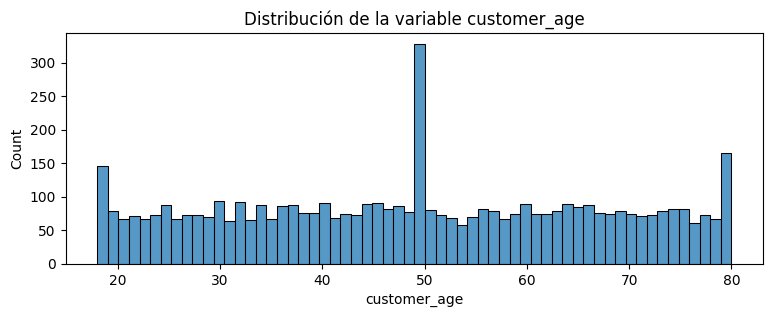

In [ ]:
# Graficar histogramas
for col in num_cols:
    plt.figure(figsize=(9, 3))
    sns.histplot(df[col], bins=60)
    plt.title(f'Distribución de la variable {col}')
    plt.show()

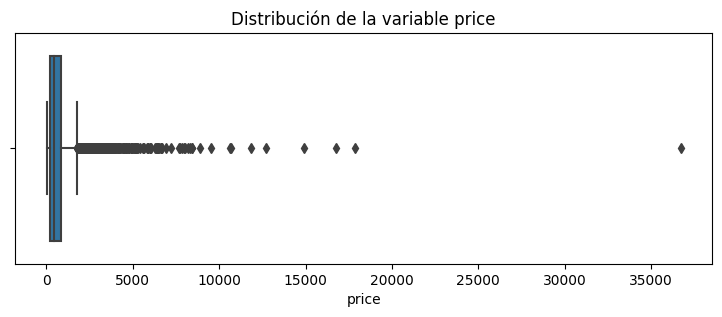

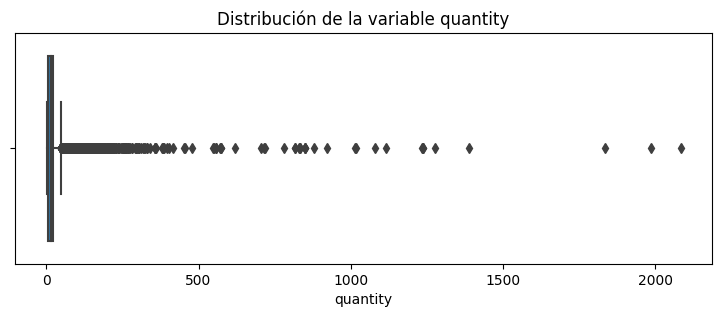

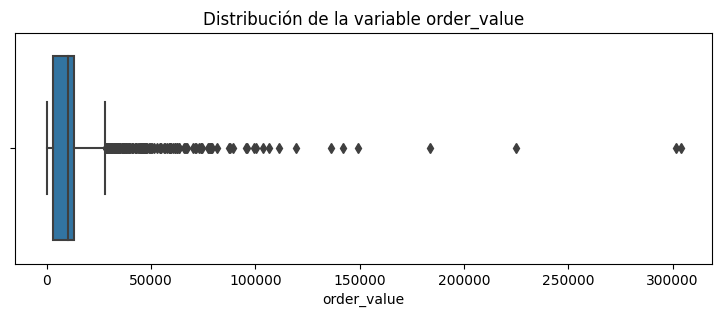

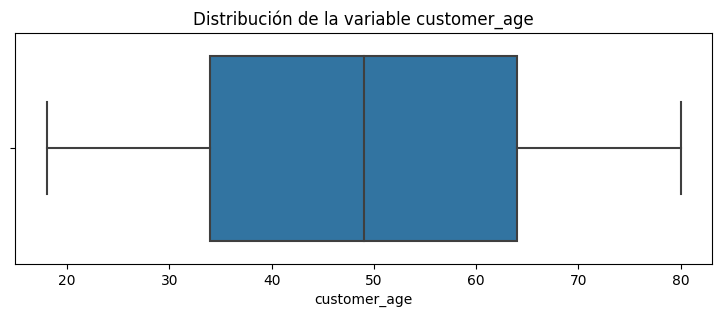

In [ ]:
# Graficar boxplots
for col in num_cols:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de la variable {col}')
    plt.show()

# 4. Identificación formal de outliers

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(col, "IQR: ", IQR)

    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    display(df[(df['price'] > upper) | (df['price'] < lower)])

price IQR:  629.25


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
64,65,2024-05-30,1651,Sports,2106,5,11155,debit_card,Phoenix,AZ,66,0,0,0
67,68,2024-05-15,2385,Home,5181,4,20724,debit_card,Miami,FL,32,1,0,0
95,96,2024-04-15,2991,Sports,1940,4,7760,credit_card,New York,NY,40,1,0,0
123,124,2024-06-21,1389,Electronics,1947,16,31152,debit_card,Boston,MA,45,1,0,0
138,139,2024-05-07,2274,Electronics,2437,6,14481,credit_card,Denver,CO,56,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4955,4956,2024-03-11,2230,Electronics,3824,6,22944,debit_card,unknown,unknown,52,1,0,1
4974,4975,2024-10-20,2627,Electronics,1985,6,12454,debit_card,New York,NY,72,0,0,0
4984,4985,2024-03-11,2509,Sports,1911,4,7644,credit_card,Miami,FL,36,1,0,0
4990,4991,2024-08-25,2569,Sports,2856,5,14616,credit_card,Los Angeles,CA,74,0,0,0


quantity IQR:  16.0


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0
1,2,2024-10-10,1736,Grocery,66,10,660,debit_card,Los Angeles,CA,24,1,0,0
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2024-03-18,1874,Electronics,1702,6,10212,paypal,Seattle,WA,20,1,0,0
4996,4997,2024-09-30,2191,Grocery,151,92,13860,credit_card,New York,NY,63,0,0,0
4997,4998,2024-10-26,2838,Electronics,2699,4,11965,credit_card,Los Angeles,CA,76,0,0,0
4998,4999,2024-09-05,1744,Sports,459,15,6885,cash,Miami,FL,45,1,0,0


order_value IQR:  10066.5


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
754,755,2024-07-22,2125,Electronics,36708,5,183540,credit_card,San Francisco,CA,42,1,0,0


customer_age IQR:  30.0


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0
5,6,2024-11-10,2824,Toys,459,29,13347,debit_card,New York,NY,57,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2024-03-18,1874,Electronics,1702,6,10212,paypal,Seattle,WA,20,1,0,0
4996,4997,2024-09-30,2191,Grocery,151,92,13860,credit_card,New York,NY,63,0,0,0
4997,4998,2024-10-26,2838,Electronics,2699,4,11965,credit_card,Los Angeles,CA,76,0,0,0
4998,4999,2024-09-05,1744,Sports,459,15,6885,cash,Miami,FL,45,1,0,0


# 5. Clasificación y tratamiento de outliers: Drop, Keep o Cap

- Drop: cuando el valor es imposible
- Keep: es un valor posible a mantener
- Winsorization: cuando es extremo pero posible

# 5.1 Winsorization (valores extremos pero posibles)
Para conservar la información del cliente típico, capamos los valores que estén por encima del percentil del 99.

In [ ]:
for col in num_cols:
    p99 = df[col].quantile(0.99)
    df[f'{col}_capped'] = np.clip(df[col], None, p99)

df[["price","price_capped", "quantity","quantity_capped",
    "order_value","order_value_capped", "customer_age","customer_age_capped"]].head()

,price,price_capped,quantity,quantity_capped,order_value,order_value_capped,customer_age,customer_age_capped
0,269,269.0,50,50.0,13385,13385.0,66,66
1,66,66.0,10,10.0,660,660.0,24,24
2,267,267.0,19,19.0,5073,5073.0,23,23
3,114,114.0,125,125.0,14290,14290.0,70,70
4,729,729.0,16,16.0,11754,11754.0,75,75


# 6. Estadísticas post-tratamiento

In [ ]:
df[["price","price_capped", "quantity","quantity_capped",
    "order_value","order_value_capped", "customer_age","customer_age_capped"]].describe()

,price,price_capped,quantity,quantity_capped,order_value,order_value_capped,customer_age,customer_age_capped
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,756.387400,725.998400,32.359800,27.930100,10075.523800,9694.762100,49.120800,49.120800
std,1173.265182,877.342942,93.403826,48.505516,12406.603152,8677.328642,17.710679,17.710679
min,12.000000,12.000000,1.000000,1.000000,12.000000,12.000000,18.000000,18.000000
25%,218.000000,218.000000,7.000000,7.000000,3094.000000,3094.000000,34.000000,34.000000
50%,457.000000,457.000000,14.000000,14.000000,10341.000000,10341.000000,49.000000,49.000000
75%,847.250000,847.250000,23.000000,23.000000,13160.500000,13160.500000,64.000000,64.000000
max,36708.000000,5148.120000,2083.000000,331.010000,303824.000000,56150.670000,80.000000,80.000000


# 7. Conclusión ejecutiva

# 7.1 Columna price:

   - El 50% de los precios se encuentra entre 218 y 847.
   - Los valores >847 USD corresponden al 25% de los precios más altos.
   - Se realizó winsorización al percentil 99 para estabilizar métricas sin perder estos segmentos.
   
# 7.2 Columna quantity

   - La distribucion de la columna quantity esta sesgada a la derecha.
   - El boxplot confirma la sospecha de outliers y outliers extremos.
   - El IQR es de 16.0 lo que quiere decir que la mayoria estan concentrados en un rango reducido.
   - Se realizó winsorización al percentil 99 para estabilizar métricas sin perder estos segmentos.
    
# 7.3 Columna order_value
    
   - La distribucion esta sesgada a la derecha.
   - El boxplot Muestra varios outliers y uno muy extremo.
   - Se realizó winsorización al percentil 99 para estabilizar métricas sin perder estos segmentos.
   - Es la columna con mayor desviacion, al winsorizarlo considerablemente el maximo, la desviacion std y la media.

# 7.4 Columna customer_age
    
   - Tiene un pico de edad en los 50 años.
   - No hay outliers y las edades se concentran entre los 35 y 65 años.
   - No fue necesario la winsorizacion para estabilizar métricas.
   - El IQR es de 30.0 por lo que no hay mucha dispersion de los datos
    